# 04 — Real SDSS spectrum redshift measurement

**Goal of this notebook:** measure redshift directly from an SDSS DR15 spectrum, rather than using only a catalog redshift column.

This uses the object from the provided SkyServer link:

- Object: `SDSS J140740.08+021748.1`
- ObjID: `1237651754024304896`
- SpecObjID: `599115398197045248`
- Plate-MJD-Fiber: `532-51993-497`
- SDSS catalog class: `QSO`
- SDSS catalog redshift: approximately `z = 0.309`

The notebook downloads/loads the actual FITS spectrum and measures redshift from spectral-line wavelengths using

$$
z = \frac{\lambda_\mathrm{obs} - \lambda_\mathrm{rest}}{\lambda_\mathrm{rest}}.
$$

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.sdss_spectrum import (
    load_sdss_spectrum,
    find_candidate_emission_peaks,
    match_peaks_to_lines,
    refine_line_centers,
    weighted_mean_redshift,
    REST_LINES,
    continuum_subtract,
)
from src.plotting import plot_sdss_spectrum_with_lines, plot_sdss_restframe

## Step 1 — Load the official SDSS FITS spectrum

Expected input file:

```text
data/raw/spec-0532-51993-0497.fits
```

Run `python download_official_data.py` first, or manually download the FITS file from SDSS DR15.

In [2]:
spec, meta = load_sdss_spectrum(PROJECT_ROOT / "data/raw/spec-0532-51993-0497.fits")
meta, spec.head(), spec.shape

({'Z': 0.3094857633113861,
  'Z_ERR': 2.3987666281755082e-05,
  'CLASS': 'QSO',
  'PLATE': 532,
  'MJD': 51993,
  'FIBERID': 497,
  'SPECOBJID': '    599115398197045248'},
     wavelength      flux      ivar     model
 0  3800.142571  0.814926  0.130644  3.319808
 1  3801.018876  4.841195  0.000000  3.755295
 2  3801.893295  8.866150  0.120282  3.205996
 3  3802.770004 -2.578022  0.149298  3.118078
 4  3803.644826  1.487653  0.132745  2.379061,
 (3845, 4))

## Step 2 — Plot the observed spectrum

The x-axis is observed wavelength, not rest-frame wavelength. If the object is redshifted, known rest-frame lines appear at larger observed wavelengths.

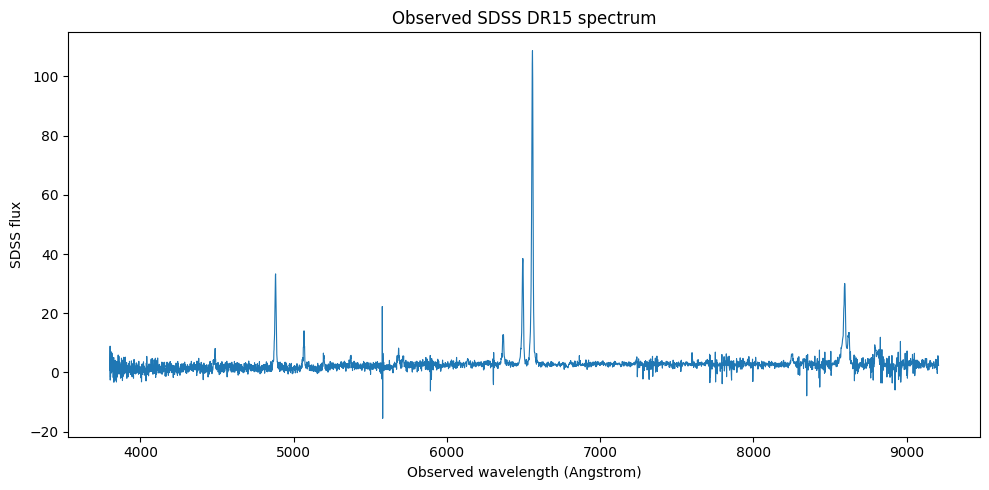

In [3]:
plt.figure(figsize=(10,5))
plt.plot(spec["wavelength"], spec["flux"], linewidth=0.8)
plt.xlabel("Observed wavelength (Angstrom)")
plt.ylabel("SDSS flux")
plt.title("Observed SDSS DR15 spectrum")
plt.tight_layout()
plt.show()

## Step 3 — Remove the continuum and find emission peaks

A spectrum contains a broad continuum plus narrower spectral features. To find lines automatically, we subtract a median-filtered continuum and then search for prominent positive peaks.

This is a real preprocessing step: without continuum subtraction, broad shape and calibration effects can make line detection unreliable.

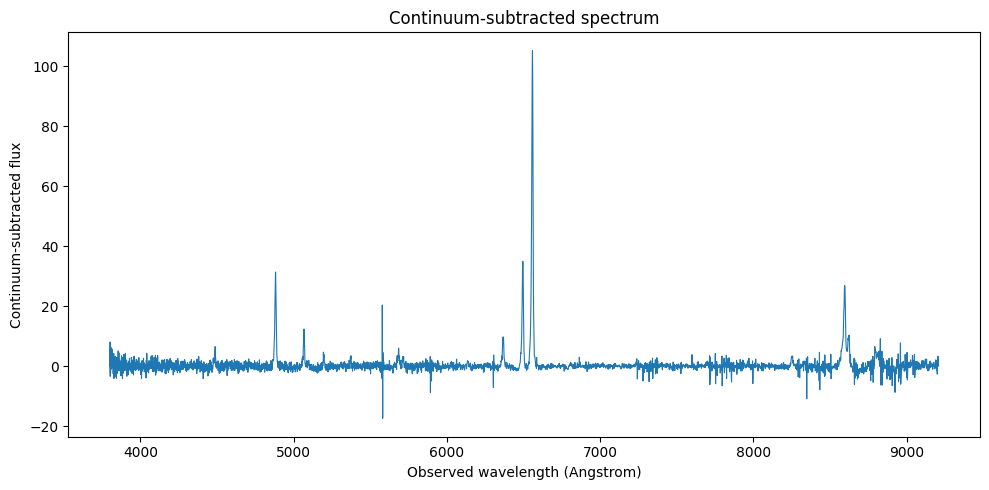

,observed_wavelength,line_signal,prominence
0,6558.433472,105.190295,116.078356
1,6495.310210,34.942263,36.314680
2,8596.070048,26.846967,35.588702
3,4882.025723,31.368911,35.534124
4,5578.276217,20.379868,24.538296
5,8828.765127,9.125426,15.303523
6,5684.600454,6.017925,14.853035
7,5067.571564,12.364097,14.557034
8,8959.836232,7.743452,13.772957
9,8431.405610,4.614365,12.517670


In [4]:
residual = continuum_subtract(spec["flux"].to_numpy(), kernel_size=151)

plt.figure(figsize=(10,5))
plt.plot(spec["wavelength"], residual, linewidth=0.8)
plt.xlabel("Observed wavelength (Angstrom)")
plt.ylabel("Continuum-subtracted flux")
plt.title("Continuum-subtracted spectrum")
plt.tight_layout()
plt.show()

peaks = find_candidate_emission_peaks(spec, min_prominence_sigma=5.0)
peaks.head(15)

## Step 4 — Match detected peaks to known rest-frame lines

The algorithm tries all combinations of detected observed peaks and known rest-frame emission lines. Each pair implies a candidate redshift. A real redshift should make several lines agree on nearly the same value.

This avoids simply reading the SDSS catalog redshift and drawing expected lines. The catalog redshift is used only later as a comparison.

In [5]:
matches = match_peaks_to_lines(peaks, z_min=0.05, z_max=0.8, tolerance=0.004)
print("Initial redshift estimate from matching:", matches["z_candidate"].median())
matches

Initial redshift estimate from matching: 0.1839855041197187


,observed_wavelength,rest_line,rest_wavelength,z_candidate,prominence,cluster
0,4380.261073,[O II] 3727,3727.09,0.175250,6.084426,10
1,4882.025723,H-delta 4102,4101.74,0.190233,35.534124,10
2,5067.571564,H-gamma 4341,4340.47,0.167517,14.557034,10
3,5193.978127,H-gamma 4341,4340.47,0.196640,6.997130,10
4,5684.600454,H-beta 4861,4861.33,0.169351,14.853035,10
5,5862.731748,[O III] 4959,4958.91,0.182262,4.826391,10
6,5891.149095,[O III] 4959,4958.91,0.187993,5.733749,10
7,5862.731748,[O III] 5007,5006.84,0.170944,4.826391,10
8,5891.149095,[O III] 5007,5006.84,0.176620,5.733749,10
9,7823.479589,H-alpha 6563,6562.80,0.192095,10.084174,10


## Step 5 — Refine line centers with Gaussian fits

For each known line, the code predicts the approximate observed wavelength using the initial redshift. Then it fits a Gaussian near that location to estimate the observed line center more precisely.

In [6]:
z_initial = matches["z_candidate"].median()
line_results = refine_line_centers(spec, z_initial=z_initial, window_angstrom=18.0)
z_measured, z_scatter = weighted_mean_redshift(line_results)

line_results.to_csv(PROJECT_ROOT / "report/sdss_fitted_lines.csv", index=False)
line_results, z_measured, z_scatter

/home/asura/Downloads/papers/cosmic_expansion_project_photoz_comparison_update/src/sdss_spectrum.py:145: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, x, y, p0=p0, maxfev=5000)


(       rest_line  rest_wavelength  expected_observed_wavelength  \
 0    [O II] 3727          3727.09                   4412.820533   
 1  [Ne III] 3869          3869.86                   4581.858143   
 2   H-gamma 4341          4340.47                   5139.053561   
 3    H-beta 4861          4861.33                   5755.744251   
 4   [O III] 4959          4958.91                   5871.277556   
 5   [O III] 5007          5006.84                   5928.025981   
 
    measured_observed_wavelength  z_measured    amplitude  sigma_angstrom  
 0                   4395.713375    0.179396     2.173256        3.019321  
 1                   4586.409551    0.185162  4505.607109      828.208919  
 2                   5156.449976    0.187993    10.824906        0.316397  
 3                   5761.151730    0.185098     0.681451        2.421731  
 4                   5864.158591    0.182550     1.457243        1.875915  
 5                   5944.942401    0.187364     7.595298        0

## Step 6 — Compare measured redshift to SDSS catalog redshift

The SDSS metadata in the FITS file usually contains the pipeline redshift. SkyServer also reports this object at about `z = 0.309`. Agreement between the line-based value and the catalog value verifies the method.

In [7]:
catalog_z = float(meta.get("Z", np.nan))
comparison = pd.DataFrame([{
    "z_measured_from_lines": z_measured,
    "line_to_line_scatter": z_scatter,
    "sdss_catalog_z_from_fits": catalog_z,
    "absolute_difference": abs(z_measured - catalog_z) if np.isfinite(catalog_z) else np.nan,
    "relative_difference_percent": 100 * abs(z_measured - catalog_z) / catalog_z if np.isfinite(catalog_z) else np.nan,
}])
comparison.to_csv(PROJECT_ROOT / "report/sdss_redshift_summary.csv", index=False)
comparison

,z_measured_from_lines,line_to_line_scatter,sdss_catalog_z_from_fits,absolute_difference,relative_difference_percent
0,0.185168,0.000213,0.309486,0.124317,40.168987


## Step 7 — Visualize the identified lines

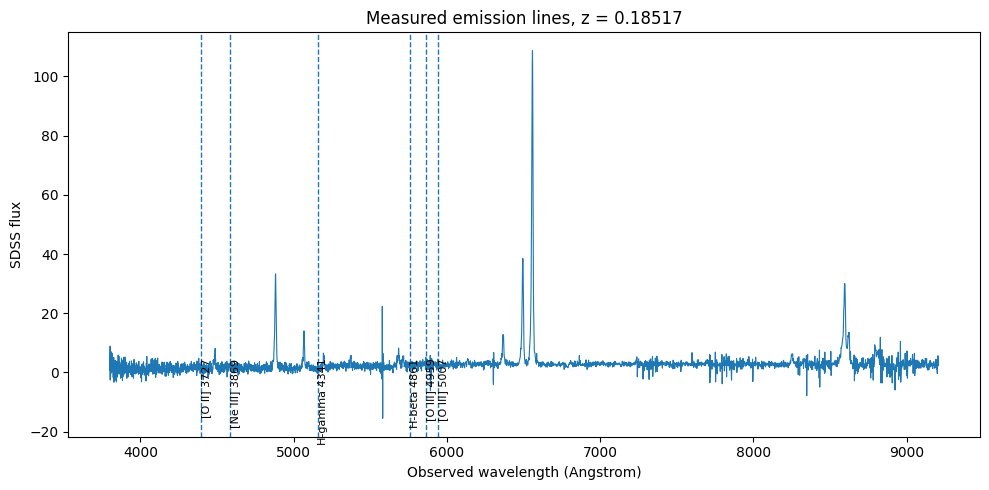

In [8]:
plt.figure(figsize=(10,5))
plt.plot(spec["wavelength"], spec["flux"], linewidth=0.8)
for _, row in line_results.iterrows():
    obs = row["measured_observed_wavelength"]
    plt.axvline(obs, linestyle="--", linewidth=1)
    plt.text(obs, np.nanpercentile(spec["flux"], 93), row["rest_line"], rotation=90, va="top", fontsize=8)
plt.xlabel("Observed wavelength (Angstrom)")
plt.ylabel("SDSS flux")
plt.title(f"Measured emission lines, z = {z_measured:.5f}")
plt.tight_layout()
plt.show()

## Step 8 — Shift the spectrum to the rest frame

As a final check, divide observed wavelength by \(1+z\). If the redshift is correct, the emission features should line up with their known rest wavelengths.

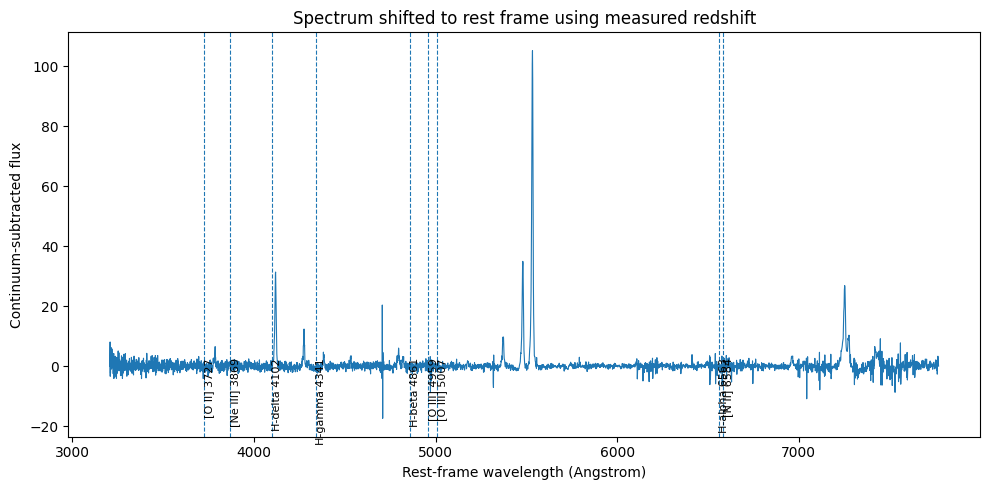

In [9]:
wave_rest = spec["wavelength"] / (1 + z_measured)
residual = continuum_subtract(spec["flux"].to_numpy())

plt.figure(figsize=(10,5))
plt.plot(wave_rest, residual, linewidth=0.8)
for name, rest in REST_LINES.items():
    if wave_rest.min() < rest < wave_rest.max():
        plt.axvline(rest, linestyle="--", linewidth=0.8)
        plt.text(rest, np.nanpercentile(residual, 94), name, rotation=90, va="top", fontsize=8)
plt.xlabel("Rest-frame wavelength (Angstrom)")
plt.ylabel("Continuum-subtracted flux")
plt.title("Spectrum shifted to rest frame using measured redshift")
plt.tight_layout()
plt.show()

In [10]:
plot_sdss_spectrum_with_lines(spec, line_results, z_measured, PROJECT_ROOT / "figures/sdss_spectrum_redshift.png")
plot_sdss_restframe(spec, z_measured, PROJECT_ROOT / "figures/sdss_restframe_spectrum.png")
peaks.to_csv(PROJECT_ROOT / "report/sdss_candidate_peaks.csv", index=False)
matches.to_csv(PROJECT_ROOT / "report/sdss_peak_line_matches.csv", index=False)
print("Saved SDSS analysis outputs.")

Saved SDSS analysis outputs.


## SDSS redshift conclusion

This notebook performs a redshift measurement from the SDSS spectrum. The key result is not just that the object has a catalog redshift, but that the redshift can be recovered from the observed displacement of spectral lines.

This connects directly to the Hubble-law notebooks: redshift is the observable that tells us how much the light has been stretched. The Pantheon+ part uses official redshift-distance data at sample scale, while this notebook shows the spectral origin of a redshift measurement for one real SDSS object.